# Credit Risk Modelling: Probability of Default

## Introduction
In this notebook, we will build and evaluate models for calculating the **Probability of Default (PD)**. PD is a frequently used metric for banks when evaluating credit risk and deciding whether to approve new clients.  

We will use **Logistic Regression**. The aim of this project is to demonstrate how this model can be applied, how to evaluate its performance, and which measures can be taken to improve performance and select optimal parameters.

---

## Data
The dataset contains fictional information about individuals who have previously taken out loans from a financial institution.   

### Columns
- **Age (integer):** Age of the person  
- **Income (integer):** Total yearly income  
- **Home ownership (category):** Type of current home ownership (rent, own, or mortgage)  
- **Employment length (decimal):** Number of years the person has been employed  
- **Loan intent (category):** Purpose of the loan (e.g., debt consolidation, personal, medical, etc.)  
- **Loan grade (category):** Grade of the loan (e.g., A, B, C, etc.)  
- **Loan amount (integer):** The amount loaned out  
- **Interest rate (decimal):** Yearly interest rate to be paid on the remaining principal  
- **Loan status (boolean):** Indicates if the loan has defaulted (0 = non-default, 1 = default)  
- **Debt to income (decimal):** Percentage of income used to service outstanding debt  
- **Defaulted before (boolean):** Whether the person has defaulted on a loan before  
- **Credit history length (integer):** Number of years the person's credit history spans  

## Data Exploration
By looking at sample data and basic summary statistics, we can understand the dataset better and spot any data problems that may need fixing.

In [338]:
# Import Library
import numpy as np
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, precision_recall_fscore_support
from sklearn.calibration import calibration_curve

In [339]:
# Read Data
file_path = r"C:\Users\BINARY\Downloads\cr_loan2.csv"
raw_data = pd.read_csv(file_path)

In [340]:
raw_data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [341]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [342]:
avg_loan_amnt = raw_data['loan_amnt'].mean()

In [343]:
# Summary statistics
raw_data.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


The average loan amount is $9589.37 ± $6322.09, with an average interest rate of 11.01% ± 3.24%.  
21.8% of all loans in our dataset have defaulted.  

We also noticed some data quality issues:  
- Age has an invalid value of 144  
- Employment length has an invalid value of 123

In [344]:
# Summary statistics for categorical values
raw_data.describe(include="O")

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836


Most people in our dataset rent their homes and take loans to pay for education.
Looking at the summary statistics, we can see that some columns have missing values. Let’s find out which columns are missing the most data.

In [345]:
# Calculate the percentage of values being NaN for each column
rows = len(raw_data)
missing = raw_data.isnull().sum()
percentage_missing = missing / rows

# Put the data in a DataFrame and sort it
percentage_missing_df = pd.DataFrame({'Missing' : percentage_missing})
percentage_missing_df.sort_values('Missing', ascending = False, inplace = True)

# Print columns with percentage of missing values
percentage_missing_df.style.format("{:.1%}")


,Missing
loan_int_rate,9.6%
person_emp_length,2.7%
person_age,0.0%
person_income,0.0%
person_home_ownership,0.0%
loan_intent,0.0%
loan_grade,0.0%
loan_amnt,0.0%
loan_status,0.0%
loan_percent_income,0.0%


We can see that the interest rate is missing in 9.6% of the rows, while age is missing in 2.7% of the rows.

In [346]:
# Find all duplicate rows
duplicates = raw_data[raw_data.duplicated(keep=False)]
    
# Count occurrences of each duplicated row
duplicate_counts = duplicates.value_counts().reset_index(name='Count')

# Group duplicate rows by their duplication count
duplicate_counts['Count'].value_counts()

Count
2    137
Name: count, dtype: int64

Our dataset of over 30,000 rows contains 137 duplicate rows, each appearing twice. Duplicate rows may indicate a data quality issue, especially if records are repeated multiple times. However, this can happen naturally since our dataset does not have unique identifiers.

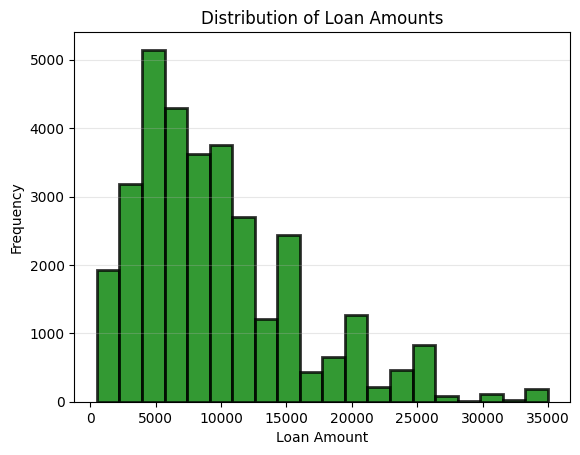

In [347]:
# Plot histogram of loan amounts
n, bins, patches = plt.hist(
    x=raw_data['loan_amnt'], 
    bins=20,             
    color='green', 
    edgecolor='black', 
    linewidth=2,          
    alpha=0.8
)
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Loan Amounts")
plt.grid(axis='y', alpha=0.3)
plt.show()

The loan amounts show a right-skewed distribution, with noticeable spikes at rounded values.

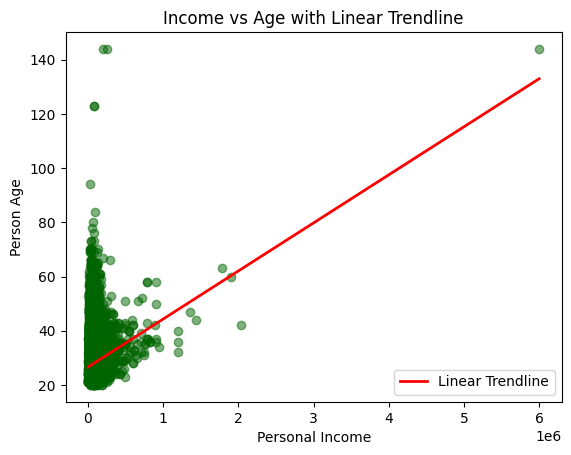

Equation of the trendline: y = 0.00001774x + 26.56


In [348]:
# Plot a scatter plot of income against age
plt.scatter(
    raw_data['person_income'], 
    raw_data['person_age'], 
    color='darkgreen',  
    alpha=0.5            
)

# Fit a linear regression model using NumPy
coefficients = np.polyfit(raw_data['person_income'], raw_data['person_age'], 1)
linear_fit = np.poly1d(coefficients)

# Generate the x values for the trendline
income_range = np.linspace(raw_data['person_income'].min(), raw_data['person_income'].max(), 100)

# Plot the trendline in red
plt.plot(
    income_range, 
    linear_fit(income_range), 
    color='red',         
    linewidth=2, 
    label='Linear Trendline'
)

plt.xlabel('Personal Income')
plt.ylabel('Person Age')
plt.title('Income vs Age with Linear Trendline')
plt.legend()
plt.show()

# Show trendline equation
slope, intercept = coefficients
equation = f'y = {slope:.8f}x + {intercept:.2f}'
print("Equation of the trendline:", equation)

By looking at a scatterplot of age versus income, we can see a positive correlation—older individuals tend to earn more, likely because they are further along in their careers. We also notice some outliers and a data issue with ages exceeding 120 years.

In Python, cross tables work like pivot tables in Excel. They provide a high-level view of selected columns with aggregations like counts or averages. For credit risk analysis, especially when modeling probability of default, columns such as loan intent and home ownership are often a good starting point for investigation.

In [349]:
# Create a cross table of the loan intent and loan status
pd.crosstab(raw_data['loan_intent'], raw_data['loan_status'], margins=True, normalize='index').style.format("{:.0%}")

loan_status,0,1
loan_intent,,
DEBTCONSOLIDATION,71%,29%
EDUCATION,83%,17%
HOMEIMPROVEMENT,74%,26%
MEDICAL,73%,27%
PERSONAL,80%,20%
VENTURE,85%,15%
All,78%,22%


Loans taken out for debt consolidation, home improvement, and medical expenses appear to have a higher default rate.

In [350]:
# Create a cross table of home ownership, loan status, and grade
pd.crosstab(raw_data['person_home_ownership'], [raw_data['loan_status'], raw_data['loan_grade']], normalize='columns').round(4).style.format("{:.0%}")

Defaulted loans seem to occur more frequently with those who rent.

In [351]:
# Create a cross table of home ownership, loan status, and average percent income
pd.crosstab(raw_data['person_home_ownership'], raw_data['loan_status'], values=raw_data['loan_percent_income'], aggfunc='mean').style.format("{:.0%}")

loan_status,0,1
person_home_ownership,,
MORTGAGE,15%,18%
OTHER,14%,30%
OWN,18%,30%
RENT,14%,26%


The debt-to-income ratio is higher for all types of home ownership among those who default compared to those who do not.

The average debt-to-income ratio is higher for defaults, suggesting that these borrowers may have already had a high debt burden at the time of loan approval.

<Figure size 1000x600 with 0 Axes>

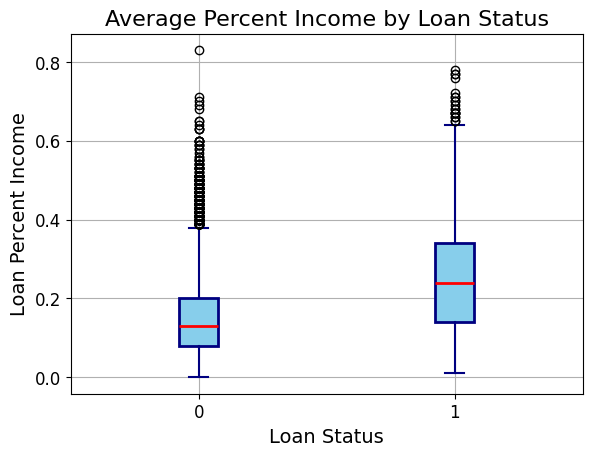

In [352]:
# Create a box plot of percentage income by loan status
plt.figure(figsize=(10, 6))

# Create the boxplot with custom styling
box = raw_data.boxplot(
    column=['loan_percent_income'], 
    by='loan_status', 
    patch_artist=True,            
    boxprops=dict(facecolor='skyblue', color='navy', linewidth=2),  
    medianprops=dict(color='red', linewidth=2),  
    whiskerprops=dict(color='navy', linewidth=1.5),  
    capprops=dict(color='navy', linewidth=1.5)       
)

# Customize labels and title
plt.title('Average Percent Income by Loan Status', fontsize=16)
plt.suptitle('')  # remove automatic subtitle
plt.ylabel('Loan Percent Income', fontsize=14)
plt.xlabel('Loan Status', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

## Data Cleaning

The first step in preparing the data is to detect and remove outliers. Outliers can make it harder for predictive models to estimate parameters accurately, which may reduce their ability to predict defaults.  

For example, an employment length over 60 months seems unrealistic, so we will remove those records from the dataset.

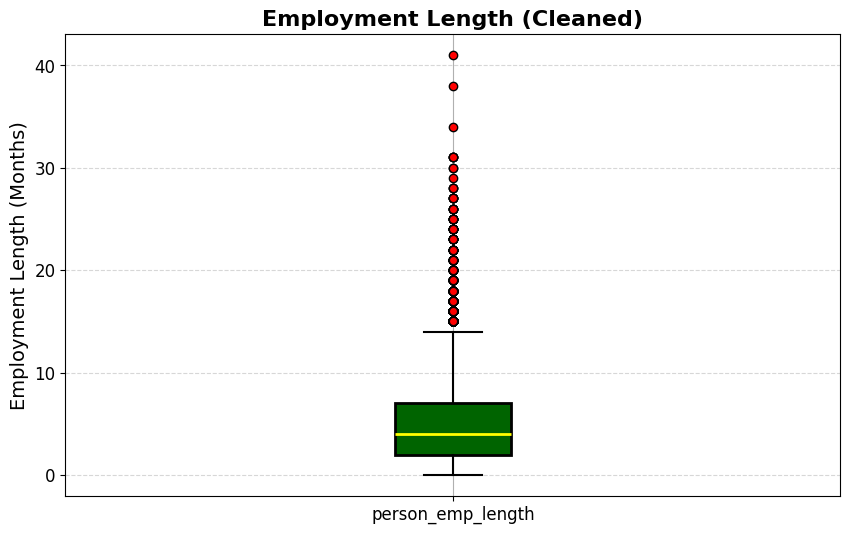

In [353]:
# Create an array of indices where employment length > 60
indices = raw_data[raw_data['person_emp_length'] > 60].index

# Drop those records to create a new dataframe
data_clean = raw_data.drop(indices)

# Create a boxplot
plt.figure(figsize=(10, 6))
box = data_clean.boxplot(
    column=['person_emp_length'],
    patch_artist=True,  # fill boxes with color
    boxprops=dict(facecolor='darkgreen', color='black', linewidth=2),   # box fill and border
    medianprops=dict(color='yellow', linewidth=2),  # median line
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5),
    flierprops=dict(marker='o', markerfacecolor='red', markersize=6, linestyle='none')  # outliers
)

plt.title('Employment Length (Cleaned)', fontsize=16, fontweight='bold')
plt.ylabel('Employment Length (Months)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

An employment length between 0 and 41 months appears reasonable.
Earlier, we also identified some records with ages over 120, so we will correct this data quality issue.

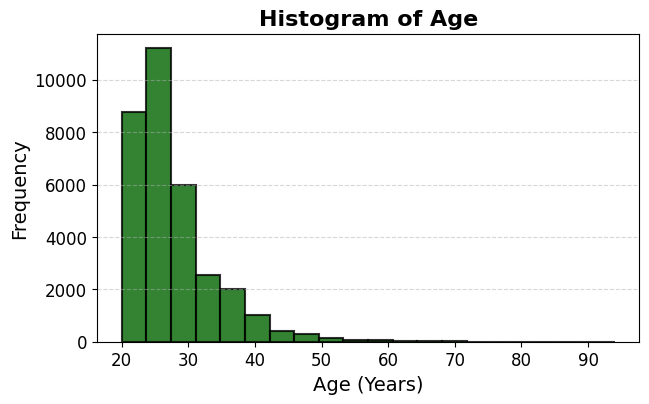

In [354]:
# Drop records where age > 100
data_clean = data_clean.drop(data_clean[data_clean['person_age'] > 100].index)

# Create a histogram for age
plt.figure(figsize=(7, 4))
n, bins, patches = plt.hist(
    data_clean['person_age'],
    bins=20,              
    color='darkgreen',       
    edgecolor='black',        
    linewidth=1.5,       
    alpha=0.8            
)

plt.title("Histogram of Age", fontsize=16, fontweight='bold')
plt.xlabel("Age (Years)", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5) 
plt.show()

We’ve addressed the outliers in both age and employment length. Next, we need to handle missing values, as they can negatively affect model performance and introduce bias in predicting defaults.

We can either drop rows with missing values or impute them using the mean or median. Previously, we saw missing values in employment length and interest rate.

Our approach is to impute employment length with the median value, while dropping rows that have missing interest rate values.

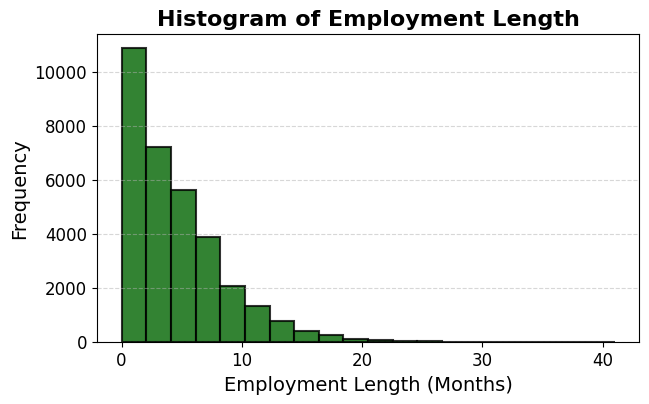

In [355]:
# Impute null values with median
data_clean['person_emp_length'].fillna(data_clean['person_emp_length'].median(), inplace=True)

# Create a \histogram
plt.figure(figsize=(7, 4))
n, bins, patches = plt.hist(
    data_clean['person_emp_length'],
    bins=20,               
    color='darkgreen',      
    edgecolor='black',     
    linewidth=1.5,           
    alpha=0.8             
)

plt.title("Histogram of Employment Length", fontsize=16, fontweight='bold')
plt.xlabel("Employment Length (Months)", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)  
plt.show()

Employment length is right-skewed, as younger individuals tend to apply for loans more often than older individuals with longer work experience.

In [356]:
# Store the array on indices
indices = data_clean[data_clean['loan_int_rate'].isnull()].index

# Save the new data without missing data
data_clean = data_clean.drop(indices)

# Calculate the percentage of values being NaN for each column
rows = len(data_clean)
missing = data_clean.isnull().sum()
percentage_missing = missing / rows

# Put the data in a DataFrame and sort it
percentage_missing_df = pd.DataFrame({'Missing' : percentage_missing})
percentage_missing_df.sort_values('Missing', ascending = False, inplace = True)

# Print columns with percentage of missing values
percentage_missing_df.style.format("{:.1%}")

,Missing
person_age,0.0%
person_income,0.0%
person_home_ownership,0.0%
person_emp_length,0.0%
loan_intent,0.0%
loan_grade,0.0%
loan_amnt,0.0%
loan_int_rate,0.0%
loan_status,0.0%
loan_percent_income,0.0%


There are now no columns with missing data, as we have either dropped the rows or imputed the missing values.

## Logistic Regression

Probability of Default (PD) measures the chance that a borrower will not repay a loan, with values ranging from 0 (no default) to 1 (default).  

We use classification models like logistic regression to predict PD based on credit features. Logistic regression produces probabilities between 0 and 1 and works well when the risk of default varies across borrowers.  

The data is split into a training set (to train the model) and a test set (to check performance on unseen data). Scikit-learn’s logistic regression automatically finds the best feature coefficients to predict default risk.

In [357]:
# Create the X and y data sets
X = data_clean[['loan_int_rate','person_emp_length','person_income', 'loan_amnt']]
y = data_clean[['loan_status']]

# Use test_train_split to create the training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.4, random_state=123)
X_test_performance = X_test[['loan_amnt']]
X_train = X_train[['loan_int_rate','person_emp_length','person_income']]
X_test = X_test[['loan_int_rate','person_emp_length','person_income']]

# Create and fit the logistic regression model
clf_logistic = LogisticRegression(solver='lbfgs').fit(X_train, np.ravel(y_train))

# Print the models coefficients
clf_logistic.coef_

array([[ 2.88774130e-01, -2.19063447e-02, -1.99385087e-05]])

These coefficients indicate how important each feature is in predicting default.  

Non-numeric columns, like `loan_intent`, need to be converted into numeric form using **one-hot encoding**. Each category becomes a separate column with 0 or 1 values. We use `pandas.get_dummies` to encode these columns and combine them with the numeric features to create a complete dataset.  

After training the model, `predict_proba` returns the predicted probabilities of non-default and default for each loan, with values between 0 and 1.

In [358]:
# Create two data sets for numeric and non-numeric data
data_num = data_clean.select_dtypes(exclude=['object'])
data_str = data_clean.select_dtypes(include=['object'])

# One-hot encode the non-numeric columns
data_str_onehot = pd.get_dummies(data_str)

# Union the one-hot encoded columns to the numeric ones
data_prep = pd.concat([data_num, data_str_onehot], axis=1)

# Print the columns in the new data set
data_prep.columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length', 'person_home_ownership_MORTGAGE',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION',
       'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT',
       'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'loan_grade_A', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D',
       'loan_grade_E', 'loan_grade_F', 'loan_grade_G',
       'cb_person_default_on_file_N', 'cb_person_default_on_file_Y'],
      dtype='object')

In [359]:
# Create the X and y data sets
X = data_prep.drop(columns=['loan_status'])
y = data_prep[['loan_status']]

# Use test_train_split to create the training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.4, random_state=123)

# Train the logistic regression model on the training data
clf_logistic = LogisticRegression(solver='lbfgs').fit(X_train, np.ravel(y_train))

# Create predictions of probability for loan status using test data
preds = clf_logistic.predict_proba(X_test)

# Create dataframes of first five predictions, and first five true labels
preds_df = pd.DataFrame(preds[:,1][0:5], columns = ['prob_default'])
true_df = y_test.head()

pd.concat([true_df.reset_index(drop = True), preds_df], axis = 1).style.format({"prob_default":"{:.1%}"})

C:\Users\BINARY\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,loan_status,prob_default
0,1,14.6%
1,1,46.7%
2,0,24.2%
3,0,10.1%
4,1,9.0%


The first five rows show low predicted probabilities of default (PD), even for loans that actually defaulted.

## Model Evaluation

We use several metrics to check how well our logistic regression model predicts defaults:

- **Accuracy**: The proportion of correct predictions (both defaults and non-defaults) out of all loans.  

- **ROC Curve (Receiver Operating Characteristic)**: Shows the trade-off between the **True Positive Rate (sensitivity)** and **False Positive Rate (1 - specificity)** at different probability thresholds.  
  - Curves closer to the top-left corner indicate better predictive performance.  
  - **AUC (Area Under the Curve)** measures how well the model separates defaults from non-defaults compared to a random guess. A higher AUC means better performance.

In [360]:
# Create a dataframe for the probabilities of default
preds_df = pd.DataFrame(preds[:,1], columns = ['prob_default'])

# Reassign loan status based on the threshold
preds_df['loan_status'] = preds_df['prob_default'].apply(lambda x: 1 if x > 0.5 else 0)

# Print the row counts for each loan status
preds_df['loan_status'].value_counts()

loan_status
0    10289
1     1495
Name: count, dtype: int64

Using a 50% PD threshold to classify defaults, we have 1495 defaulted loans (loan_status = 1) and 10289 non-defaulted loans (loan_status = 0).

In [361]:
# Print the classification report
target_names = ['Non-Default', 'Default']
print(classification_report(y_test, preds_df['loan_status'], target_names=target_names))

              precision    recall  f1-score   support

 Non-Default       0.84      0.94      0.89      9198
     Default       0.66      0.38      0.48      2586

    accuracy                           0.82     11784
   macro avg       0.75      0.66      0.69     11784
weighted avg       0.80      0.82      0.80     11784



## Model Performance

The logistic regression model performs very well at predicting non-default loans, with a precision of 84%, recall of 94%, and F1-score of 89%. For defaulted loans, performance is moderate, with a precision of 66%, recall of 38%, and F1-score of 48%, meaning the model correctly identifies only 38% of actual defaults. Overall accuracy is 82%, with a macro average of 75% precision, 66% recall, and 69% F1-score, and a weighted average of 80% precision, 82% recall, and 80% F1-score. This indicates that the model is much better at identifying non-defaults than defaults, which is important to consider in credit risk management because missed defaults can be costly.

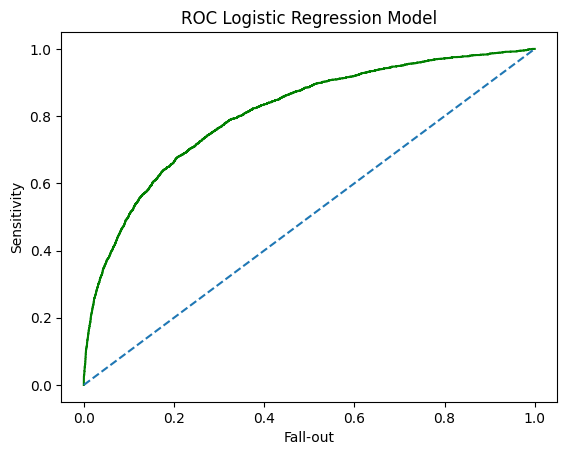

Accuracy: 0.8203496266123558
AUC: 0.808959066221565


In [362]:
# Create predictions and store them in a variable
preds = clf_logistic.predict_proba(X_test)

# Plot the ROC curve of the probabilities of default
prob_default = preds[:, 1]
fallout, sensitivity, thresholds = roc_curve(y_test, prob_default)
plt.plot(fallout, sensitivity, color='green') 
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("Fall-out")
plt.ylabel("Sensitivity")
plt.title("ROC Logistic Regression Model")
plt.show()

# Compute the AUC and store it in a variable
auc = roc_auc_score(y_test, prob_default)
                                   
# Print the accuracy and AUC score of the model
print("Accuracy:", clf_logistic.score(X_test, y_test))
print("AUC:", auc)

The ROC curve shows the trade-off between the false positive rate (x-axis) and true positive rate (y-axis). The model achieves an accuracy of 82% and an AUC score of 0.81, indicating good overall predictive performance.

In [363]:
# Set the threshold for defaults to 0.5
preds_df['loan_status'] = preds_df['prob_default'].apply(lambda x: 1 if x > 0.5 else 0)

# Print the confusion matrix
print("Default threshold 50%\n", confusion_matrix(y_test,preds_df['loan_status']),"\n")

# Set the threshold for defaults to 0.4
preds_df['loan_status'] = preds_df['prob_default'].apply(lambda x: 1 if x > 0.4 else 0)

# Print the confusion matrix
print("Default threshold 40%\n", confusion_matrix(y_test,preds_df['loan_status']))

Default threshold 50%
 [[8685  513]
 [1604  982]] 

Default threshold 40%
 [[8190 1008]
 [1232 1354]]


The confusion matrix summarizes true/false positives and negatives.
Default threshold 50%: 982 defaults correctly identified, 1,604 missed.
Default threshold 40%: 1,354 defaults correctly identified, 1,232 missed.
Lowering the PD threshold to 40% improves default recall, catching more actual defaults.

In [364]:
# Reassign the values of loan status based on the new threshold
preds_df['loan_status'] = preds_df['prob_default'].apply(lambda x: 1 if x > 0.4 else 0)

# Store the number of loan defaults from the prediction data
num_defaults = preds_df['loan_status'].value_counts()[1]

# Store the default recall from the classification report
default_recall = precision_recall_fscore_support(y_test,preds_df['loan_status'])[1][1]

# Calculate the estimated impact of the new default recall rate
print(num_defaults * avg_loan_amnt * (1 - default_recall))

10790764.303214505


The unexpected loss is calculated by multiplying the loans that defaulted but were not predicted by the average loan amount. At a PD threshold of 40%, the unexpected loss is approximately $10.79M.

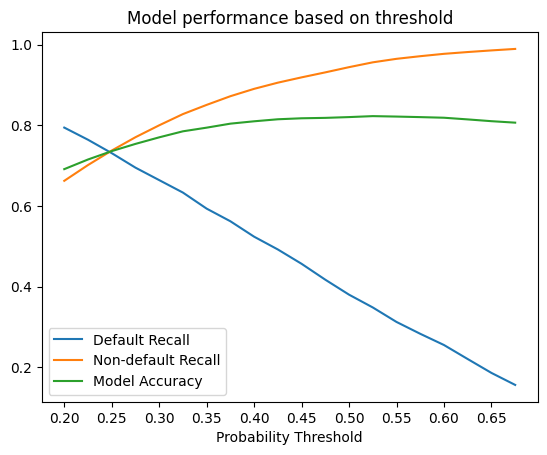

[np.float64(0.0064757344101336045), 0.25]

In [365]:
thresh = [0.2 + i * 0.025 for i in range(20)]
ticks = [thresh[i] for i in range(len(thresh)) if i % 2 == 0]
def_recalls = []
nondef_recalls = []
accs = []

for thresh_value in thresh:
    # Reassign the values of loan status based on the new threshold
    preds_df['loan_status'] = preds_df['prob_default'].apply(lambda x: 1 if x > thresh_value else 0)

    # Store the default recall from the classification report
    default_recall = precision_recall_fscore_support(y_test, preds_df['loan_status'])[1][1]
    nondefault_recall = precision_recall_fscore_support(y_test,preds_df['loan_status'])[1][0]
    accuracy = accuracy_score(y_test,preds_df['loan_status'])

    # Append the default recall value to the list
    def_recalls.append(default_recall)
    nondef_recalls.append(nondefault_recall)
    accs.append(accuracy)

plt.plot(thresh,def_recalls)
plt.plot(thresh,nondef_recalls)
plt.plot(thresh,accs)
plt.xlabel("Probability Threshold")
plt.xticks(ticks)
plt.legend(["Default Recall","Non-default Recall","Model Accuracy"])
plt.title("Model performance based on threshold")
plt.show()

# Find the threshold where default recall and non-default recall intersect
intersect = [1, 1]
for i, thresh_value in enumerate(thresh):
    difference = abs(def_recalls[i] - nondef_recalls[i])
    if (difference < intersect[0]):
        intersect = [difference, thresh_value]
        
intersect

There is a trade-off between default recall, non-default recall, and overall accuracy. Based on these metrics, the optimal threshold is around PD = 0.25. At very low thresholds (starting near 0.0065), the model shows high sensitivity to defaults, but classifying all loans above 0.25 as defaults may not be practical. This analysis helps guide threshold selection while balancing the risk of missed defaults and false alarms.

## Conclusion

In this project, we started by exploring the loan data to identify missing values and outliers. We addressed these issues through basic data cleaning steps.  

We then built a **logistic regression model** to predict the probability of default (PD). Categorical columns were one-hot encoded so they could be used in the model, and feature coefficients were examined to identify the most important predictors. By splitting the data into training and test sets, we were able to evaluate model performance using precision, recall, and the AUC of the ROC curve. We also analyzed the trade-off between default recall and non-default recall to select an optimal PD threshold for classifying loans.  

Finally, we showed how this threshold can guide loan approval decisions by balancing the number of predicted defaults with the overall acceptance rate. This helps in estimating the expected loss in a loan portfolio and making informed credit risk decisions.